## DSA2101 Midterm

In [1]:
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

1.1

In [2]:
shutdown = pd.read_csv('../data/midterm_shutdown.csv')

qn1_1 = shutdown.rename(columns = {
    'Value' : 'Shutdown',
}).copy()

qn1_1 = qn1_1.groupby(['Industry', 'year'])['Shutdown'].agg('sum').reset_index()

qn1_1 = qn1_1.rename(columns = {
    'year': 'Year'
})

rows1, cols1 = qn1_1.shape
print(f'qn1_1 has {rows1} rows and {cols1} columns.')
qn1_1.tail()

qn1_1 has 518 rows and 3 columns.


,Industry,Year,Shutdown
513,Wholesale Trade,2022,8910
514,Wholesale Trade,2023,9093
515,Wholesale Trade,2024,9251
516,Wholesale Trade,2025,9980
517,Wholesale Trade,2026,741


1.2

In [3]:
formation = pd.read_csv('../data/midterm_formation.csv')

qn1_2 = formation.melt(id_vars = 'Industry', var_name = 'Year', value_name = 'Formation').copy()

qn1_2['Year'] = qn1_2['Year'].astype('Int64')

rows2, cols2 = qn1_2.shape

print(f'qn1_2 has {rows2} rows and {cols2} columns.')
qn1_2.head()

qn1_2 has 504 rows and 3 columns.


,Industry,Year,Formation
0,Manufacturing,2025,2583
1,Construction,2025,3718
2,Wholesale Trade,2025,12048
3,Retail Trade,2025,7701
4,Transportation & Storage,2025,3886


1.3

In [4]:
print(qn1_1['Industry'].isna().sum())
print(qn1_2['Industry'].isna().sum())
print(qn1_1['Year'].isna().sum())
print(qn1_2['Year'].isna().sum())

0
0
0
0


In [5]:
qn1_3 = (qn1_2.merge(qn1_1, how = 'left', on = ['Year', 'Industry'])
         .sort_values(by = ['Year', 'Industry'], ascending = [False, True])
         ).reset_index(drop = True).copy()

qn1_3 = qn1_3[['Year', 'Industry', 'Formation', 'Shutdown']]

rows3, cols3 = qn1_3.shape

print(f'qn1_3 has {rows3} rows and {cols3} columns.')
qn1_3.head()

qn1_3 has 504 rows and 4 columns.


,Year,Industry,Formation,Shutdown
0,2025,Accommodation,111,64
1,2025,Administrative & Support Services,3245,2550
2,2025,"Arts, Entertainment, Recreation",4708,3736
3,2025,Construction,3718,2737
4,2025,"Education, Health & Social Services",4059,2985


1.4

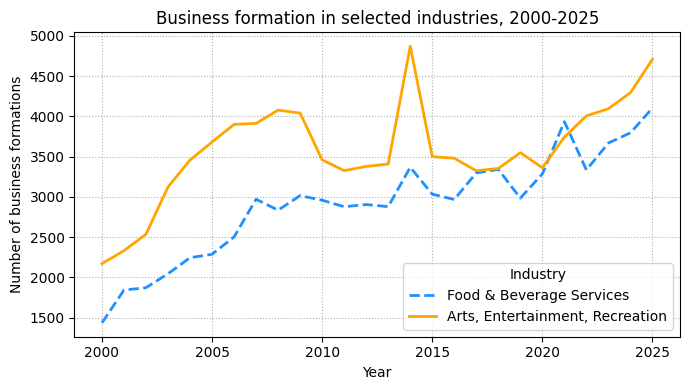

In [6]:
qn1_4 = qn1_3[qn1_3['Industry'].isin(['Food & Beverage Services', 'Arts, Entertainment, Recreation'])].copy()
qn1_4 = qn1_4.query('Year >= 2000 and Year <= 2025 ')

qn1_4 = qn1_4.pivot(index = 'Year', columns = 'Industry', values = 'Formation').reset_index()
qn1_4.columns.name = None

qn1_4.plot(kind = 'line',
           figsize = (7, 4),
           x = 'Year',
           y = ['Food & Beverage Services', 'Arts, Entertainment, Recreation'],
           ylabel = 'Number of business formations',
           title = 'Business formation in selected industries, 2000-2025',
           style = ['--', '-'],
           linewidth = 2,
           color = ['dodgerblue','orange'])
plt.legend(title = 'Industry', loc = 'lower right')
plt.grid(ls = ':')
plt.tight_layout()
plt.show()